In [ ]:
from google.colab import files
uploaded=files.upload()

Saving customer_booking.csv to customer_booking (1).csv


In [ ]:
import pandas as pd
df=pd.read_csv('customer_booking.csv',encoding="ISO-8859-1")

In [ ]:
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

In [ ]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


In [ ]:
df.isnull().sum()

,0
num_passengers,0
sales_channel,0
trip_type,0
purchase_lead,0
length_of_stay,0
flight_hour,0
flight_day,0
route,0
booking_origin,0
wants_extra_baggage,0


In [ ]:
df.duplicated().sum()

np.int64(719)

In [ ]:
df['flight_day'].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [ ]:
mapping={
    'Mon':1,
    'Tue':2,
    'Wed':3,
    'Thu':4,
    'Fri':5,
    'Sat':6,
    'Sun':7
}

df['flight_day']=df['flight_day'].map(mapping)

In [ ]:
df['flight_day'].unique()

array([6, 3, 4, 1, 7, 2, 5])

In [ ]:
df['sales_channel']=df['sales_channel'].astype('category').cat.codes

In [ ]:
df['sales_channel'].unique()

array([0, 1], dtype=int8)

In [ ]:
df=df.drop_duplicates()
df.reset_index(drop=True)

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,0,RoundTrip,262,19,7,6,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,0,RoundTrip,112,20,3,6,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,0,RoundTrip,243,22,17,3,AKLDEL,India,1,1,0,5.52,0
3,1,0,RoundTrip,96,31,4,6,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,0,RoundTrip,68,22,15,3,AKLDEL,India,1,0,1,5.52,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49276,2,0,RoundTrip,27,6,9,6,PERPNH,Australia,1,0,1,5.62,0
49277,1,0,RoundTrip,111,6,4,7,PERPNH,Australia,0,0,0,5.62,0
49278,1,0,RoundTrip,24,6,22,6,PERPNH,Australia,0,0,1,5.62,0
49279,1,0,RoundTrip,15,6,11,1,PERPNH,Australia,1,0,1,5.62,0


In [ ]:
df.shape

(49281, 14)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['trip_type']=df['trip_type'].astype('category').cat.codes

/tmp/ipykernel_1121/781002750.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['trip_type']=df['trip_type'].astype('category').cat.codes


In [ ]:
df['route']=df['route'].astype('category').cat.codes

/tmp/ipykernel_1121/345771839.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['route']=df['route'].astype('category').cat.codes


In [ ]:
df['booking_origin']=df['booking_origin'].astype('category').cat.codes

/tmp/ipykernel_1121/2269926933.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['booking_origin']=df['booking_origin'].astype('category').cat.codes


In [ ]:
df.head(2)

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,0,2,262,19,7,6,0,61,1,0,0,5.52,0
1,1,0,2,112,20,3,6,0,61,0,0,0,5.52,0


# **Data Visualisation(EDA)**

In [ ]:
df.describe()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,49281.000000,49281.000000,49281.000000,49281.000000,49281.000000,49281.000000,49281.000000,49281.000000,49281.000000,49281.000000,49281.000000,49281.000000,49281.000000,49281.000000
mean,1.590187,0.108845,1.987460,84.723281,23.053976,9.070676,3.813620,392.313305,38.249589,0.668229,0.295631,0.426635,7.279974,0.149977
std,1.016538,0.311448,0.130733,90.410229,33.832149,5.413099,1.991913,227.270431,32.785767,0.470854,0.456331,0.494593,1.496390,0.357052
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,0.000000,2.000000,21.000000,5.000000,5.000000,2.000000,203.000000,4.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,0.000000,2.000000,51.000000,17.000000,9.000000,4.000000,382.000000,37.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,0.000000,2.000000,115.000000,28.000000,13.000000,5.000000,611.000000,58.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,1.000000,2.000000,867.000000,778.000000,23.000000,7.000000,798.000000,103.000000,1.000000,1.000000,1.000000,9.500000,1.000000


/tmp/ipykernel_1121/946538241.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='booking_complete',data=df,palette='Set2')


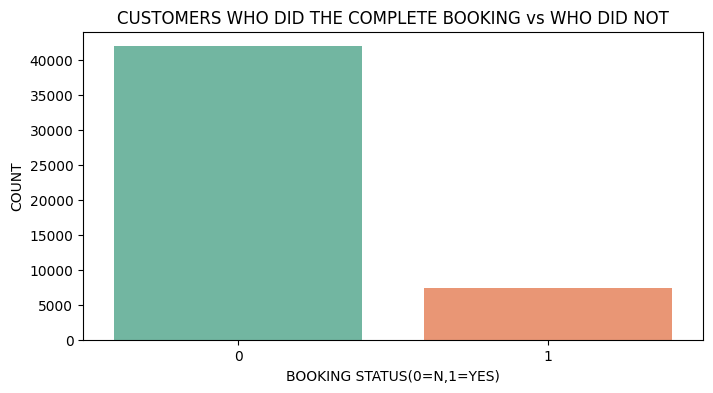

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.countplot(x='booking_complete',data=df,palette='Set2')
plt.title('CUSTOMERS WHO DID THE COMPLETE BOOKING vs WHO DID NOT')
plt.xlabel('BOOKING STATUS(0=N,1=YES)')
plt.ylabel('COUNT')
plt.show()

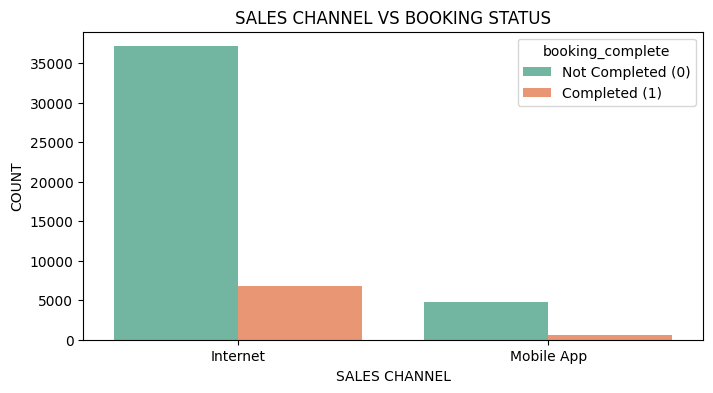

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(data=df,x='sales_channel',hue='booking_complete',palette='Set2')
plt.xticks(ticks=[0, 1], labels=['Internet', 'Mobile App'])
plt.title('SALES CHANNEL VS BOOKING STATUS')
plt.xlabel('SALES CHANNEL')
plt.ylabel('COUNT')
plt.legend(title='booking_complete', labels=['Not Completed (0)', 'Completed (1)'])
plt.show()


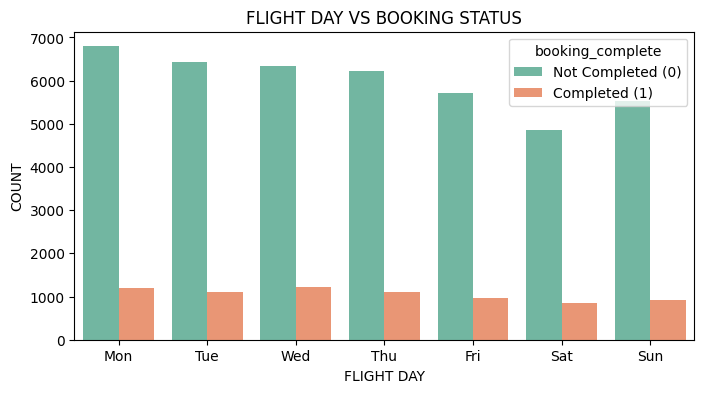

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(x='flight_day',data=df,hue='booking_complete',palette='Set2')
plt.xticks(ticks=[0,1,2,3,4,5,6], labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.title('FLIGHT DAY VS BOOKING STATUS')
plt.xlabel('FLIGHT DAY')
plt.ylabel('COUNT')
plt.legend(title='booking_complete', labels=['Not Completed (0)', 'Completed (1)'])
plt.show()


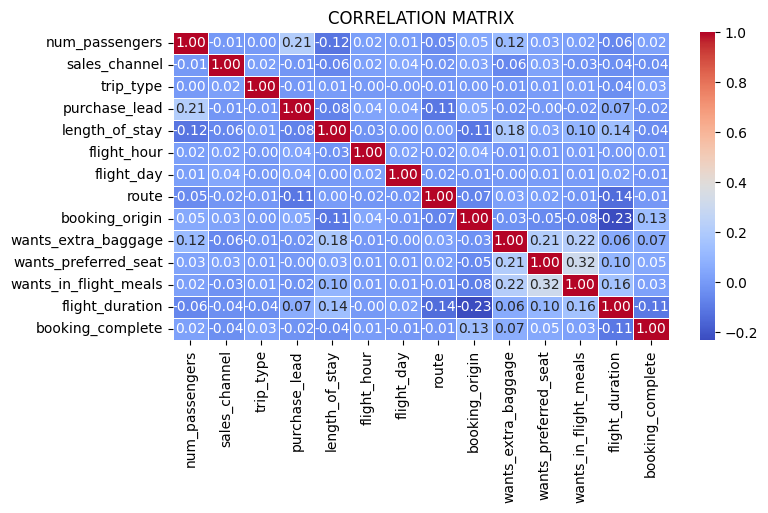

In [ ]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title('CORRELATION MATRIX')
plt.show()


# **Train the model**
*Random* *Forest*

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

X=df.drop(columns=['booking_complete'])
y=df['booking_complete']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=12,
    min_samples_split=10,
    class_weight='balanced'
)
rf_model.fit(X_train,y_train)



y_pred=rf_model.predict(X_test)

accuracy=accuracy_score(y_test,y_pred)
classification=classification_report(y_test,y_pred)
confusion=confusion_matrix(y_test,y_pred)

print(f"Overall Accuracy Score: {accuracy_score(y_test, y_pred)*100:.2f}%\n")
print('Classification Report:\n',classification)
print('Confusion Matrix:\n',confusion)



Overall Accuracy Score: 74.74%

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.77      0.84      8378
           1       0.32      0.63      0.43      1479

    accuracy                           0.75      9857
   macro avg       0.62      0.70      0.63      9857
weighted avg       0.83      0.75      0.78      9857

Confusion Matrix:
 [[6436 1942]
 [ 548  931]]


/tmp/ipykernel_1121/2238091162.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


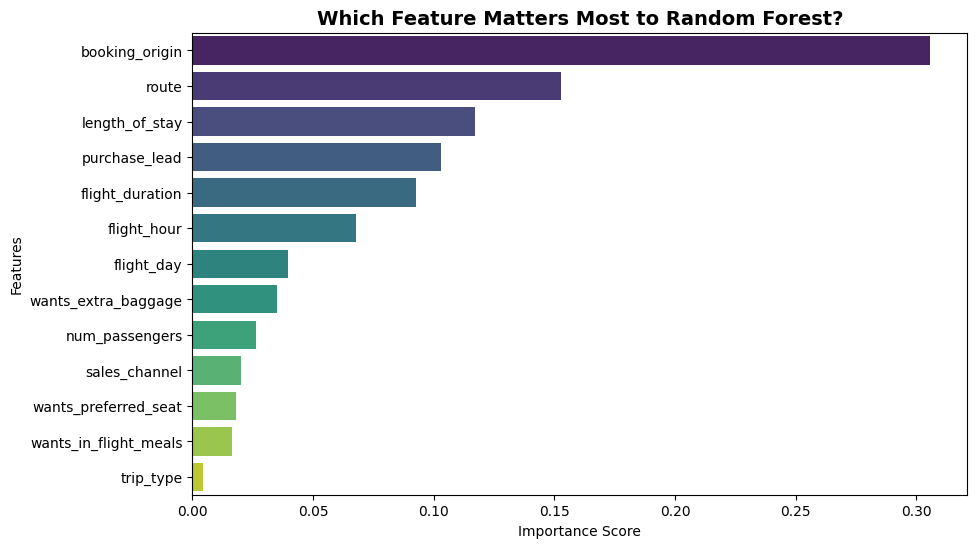

In [ ]:

importances = rf_model.feature_importances_
feature_names = X.columns


feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Which Feature Matters Most to Random Forest?', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()